## LSTM and CNN With sliding window

### LIbrary and Paths Imports

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import shutil
import os
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Input, Dropout, Conv1D, MaxPooling1D, Flatten)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import recall_score, confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.layers import BatchNormalization

import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import random

WINDOW_SIZE = 10
N_CLASSES = 3
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 0.001

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

BASE_PATH = Path.cwd().parent.parent
SCALED_PATH = BASE_PATH / "data" / "model-live" / "scaled"
MODEL_PATH = BASE_PATH / "models"
ASSETS_PATH = BASE_PATH/ "assets"/ "live"
artifacts_path = BASE_PATH/ "artifacts"
artifacts_path.mkdir(parents=True, exist_ok=True)


### Data Loading

In [64]:
# Load data that has been scaled.
# Loading the Robust Scaled data and then, switch to Standard Scaled data later for comparison.

# Load scaled data (ROBUST versions)
X_train = pd.read_csv(SCALED_PATH / "X_train_robust_live_data.csv")
X_val   = pd.read_csv(SCALED_PATH / "X_val_robust_live_data.csv")
X_test  = pd.read_csv(SCALED_PATH / "X_test_robust_live_data.csv")

y_train = pd.read_csv(SCALED_PATH / "y_train_live.csv").squeeze()
y_val   = pd.read_csv(SCALED_PATH / "y_val_live.csv").squeeze()
y_test  = pd.read_csv(SCALED_PATH / "y_test_live.csv").squeeze()

train_meta = pd.read_csv(SCALED_PATH / "train_meta.csv")
val_meta   = pd.read_csv(SCALED_PATH / "val_meta.csv")
test_meta  = pd.read_csv(SCALED_PATH / "test_meta.csv")

train_scenario_ids = train_meta["scenario_id"].values
train_timesteps    = train_meta["timestep"].values

val_scenario_ids = val_meta["scenario_id"].values
val_timesteps    = val_meta["timestep"].values

test_scenario_ids = test_meta["scenario_id"].values
test_timesteps    = test_meta["timestep"].values


N_FEATURES = X_train.shape[1]

# Verify shapes
print("DATA SHAPES")
print("-" * 30)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")
print(f"Features: {N_FEATURES}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Input shape per sequence: ({WINDOW_SIZE}, {N_FEATURES})")

DATA SHAPES
------------------------------
X_train: (23100, 71) | y_train: (23100,)
X_val  : (4200, 71)   | y_val  : (4200,)
X_test : (4200, 71)  | y_test : (4200,)
Features: 71
Window size: 10
Input shape per sequence: (10, 71)


### Building Sequence using Scenario Id

In [65]:
def build_sequences(X, y, window_size):
    """
    Slide a window over a single scenario's timesteps.
    Label = label of the LAST timestep in each window.
    """
    sequences = []
    labels = []

    for i in range(window_size, len(X) + 1):
        window = X[i - window_size : i]
        label  = y.iloc[i - 1]
        sequences.append(window)
        labels.append(label)

    return np.array(sequences), np.array(labels)

def build_sequences_safe(X_df, y_series, scenario_ids, window_size=WINDOW_SIZE):
    """
    Calls build_sequences per scenario so windows never
    span two different scenarios.
    """
    all_X, all_y = [], []

    for scenario in np.unique(scenario_ids):
        mask     = scenario_ids == scenario
        X_sc     = X_df[mask]
        y_sc     = y_series[mask]

        # skip scenarios too short to fill one window
        if len(X_sc) < window_size:
            continue

        Xs, ys = build_sequences(X_sc, y_sc, window_size)
        all_X.append(Xs)
        all_y.append(ys)

    return np.concatenate(all_X), np.concatenate(all_y)

X_train_seq, y_train_seq = build_sequences_safe(
    X_train, y_train, train_scenario_ids)

X_val_seq, y_val_seq = build_sequences_safe(
    X_val, y_val, val_scenario_ids)

X_test_seq, y_test_seq = build_sequences_safe(
    X_test, y_test, test_scenario_ids)

print("SEQUENCE SHAPES")
print("-" * 30)
print(f"X_train_seq : {X_train_seq.shape}")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")


SEQUENCE SHAPES
------------------------------
X_train_seq : (22803, 10, 71)
X_val_seq   : (4146, 10, 71)
X_test_seq  : (4146, 10, 71)


### One Hot Encoding using to_categorical

In [66]:
# Keras softmax needs (n, 3)
y_train_cat = to_categorical(y_train_seq, num_classes=N_CLASSES)
y_val_cat   = to_categorical(y_val_seq,   num_classes=N_CLASSES)
y_test_cat  = to_categorical(y_test_seq,  num_classes=N_CLASSES)

print("\nONE-HOT SHAPES")
print("-" * 30)
print(f"y_train_cat : {y_train_cat.shape}")
print(f"y_val_cat   : {y_val_cat.shape}")
print(f"y_test_cat  : {y_test_cat.shape}")


ONE-HOT SHAPES
------------------------------
y_train_cat : (22803, 3)
y_val_cat   : (4146, 3)
y_test_cat  : (4146, 3)


### Building MLP (Multi layer Perceptron) -> Base Model

In [67]:
def build_mlp(input_shape,n_classes, learning_rate):
    model = Sequential([
        Input(shape = input_shape),
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(n_classes, activation = 'softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

mlp_model = build_mlp(
    input_shape=(WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes = N_CLASSES,
    learning_rate=0.0001
)

mlp_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 710)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       182,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,155 (879.51 KB)

 Trainable params: 224,259 (876.01 KB)

 Non-trainable params: 896 (3.50 KB)

### Build LSTM and CNN models

In [68]:
def build_lstm(input_shape, n_classes, learning_rate):
    model = Sequential([
        Input(shape=input_shape),
        GaussianNoise(0.005),

        LSTM(128,
             return_sequences=True,
             kernel_regularizer=l2(0.0005),
             recurrent_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64,
             return_sequences=False,
             kernel_regularizer=l2(0.0005),
             recurrent_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm(
    input_shape=(WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes=N_CLASSES,
    learning_rate = LEARNING_RATE
)

lstm_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_3                │ (None, 10, 71)         │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 10, 128)        │       102,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,755 (604.51 KB)

 Trainable params: 154,371 (603.01 KB)

 Non-trainable params: 384 (1.50 KB)

In [69]:
def build_cnn(input_shape, n_classes, learning_rate):

    model = Sequential([
        Conv1D(filters=64, kernel_size=3,
               activation="relu",
               kernel_regularizer=l2(0.0005),
               input_shape=input_shape),

        BatchNormalization(),   # to reduce internal covariance shift
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters= 128, kernel_size=3,
               activation="relu",
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        Flatten(),   # flattening to 1D vector
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate, clipnorm=1.0),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn_model = build_cnn(
    input_shape = (WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes = N_CLASSES,
    learning_rate = LEARNING_RATE
)

cnn_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 8, 64)          │        13,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 2, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,811 (218.01 KB)

 Trainable params: 55,427 (216.51 KB)

 Non-trainable params: 384 (1.50 KB)

### Model Callbacks

In [70]:
def get_callbacks(model_name):
    return[
        EarlyStopping(
            monitor = "val_loss",
            patience = 15,
            restore_best_weights = True,
            min_delta = 0.001,
        ),
        ModelCheckpoint(
            filepath= artifacts_path/ f"{model_name}_best_live_model.keras",
            monitor = "val_loss",
            save_best_only = True,
            mode = "min",
            verbose = 1
        )
    ]

### Training MLP

In [71]:
start_time = time.time()
print(start_time)

mlp_history = mlp_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mlp"),
    verbose=1
)

end_time = time.time()
print(f"\nTraining time : {(end_time - start_time):.1f}s  "
      f"({(end_time - start_time) / 60:.1f} mins)")
print(f"Stopped at epoch: {len(mlp_history.history['loss'])}")

1777965603.6321385
Epoch 1/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5406 - loss: 1.0289
Epoch 1: val_loss improved from None to 0.90371, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/mlp_best_live_model.keras

Epoch 1: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/mlp_best_live_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6504 - loss: 0.7879 - val_accuracy: 0.5000 - val_loss: 0.9037
Epoch 2/100
176/179 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7990 - loss: 0.4743
Epoch 2: val_loss did not improve from 0.90371
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8154 - loss: 0.4346 - val_accuracy: 0.5000 - val_loss: 1.0176
Epoch 3/100
177/179 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8526 - loss: 0.3464
Epoch 3: val_loss did not improve from 0.90371
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8608 - loss: 0.3261 - val_ac

### Training LSTM

In [72]:
start_time = time.time()
print(start_time)

lstm_history = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

end_time = time.time()
print(f"\nTraining time : {(end_time - start_time):.1f}s  "
      f"({(end_time - start_time) / 60:.1f} mins)")
print(f"Stopped at epoch: {len(lstm_history.history['loss'])}")

1777965632.975859
Epoch 1/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8614 - loss: 0.5678
Epoch 1: val_loss improved from None to 1.08816, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/lstm_best_live_model.keras

Epoch 1: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/lstm_best_live_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.9467 - loss: 0.3534 - val_accuracy: 0.8225 - val_loss: 1.0882
Epoch 2/100
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9958 - loss: 0.1775
Epoch 2: val_loss improved from 1.08816 to 0.54086, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/lstm_best_live_model.keras

Epoch 2: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/lstm_best_live_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9965 - l

### Training CNN

In [73]:
start_time = time.time()
print(start_time)

cnn_history = cnn_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("cnn"),
    verbose=1
)

end_time = time.time()
print(f"\nTraining time : {(end_time - start_time):.1f}s  "
      f"({(end_time - start_time) / 60:.1f} mins)")
print(f"Stopped at epoch: {len(cnn_history.history['loss'])}")

1777965882.772467
Epoch 1/100
173/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7190 - loss: 0.6878
Epoch 1: val_loss improved from None to 0.51808, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/cnn_best_live_model.keras

Epoch 1: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/artifacts/cnn_best_live_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8440 - loss: 0.4208 - val_accuracy: 0.7641 - val_loss: 0.5181
Epoch 2/100
174/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9568 - loss: 0.1670
Epoch 2: val_loss did not improve from 0.51808
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9548 - loss: 0.1643 - val_accuracy: 0.7713 - val_loss: 3.7121
Epoch 3/100
172/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9844 - loss: 0.0947
Epoch 3: val_loss did not improve from 0.51808
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9850 - loss: 0.0918 - val_acc

### Plot Training accuracy

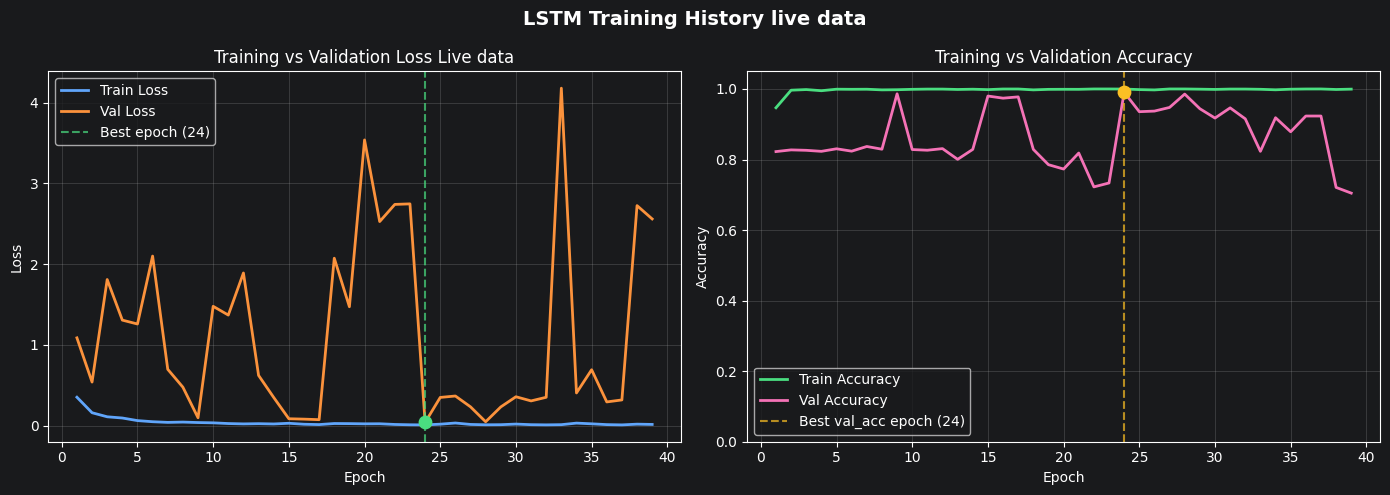


LSTM TRAINING DIAGNOSIS
----------------------------------------
Total epochs run      : 39
Best val_loss         : 0.0411  (epoch 24)
Best val_accuracy     : 0.9906  (epoch 24)
Train accuracy @ best : 0.9998
Val accuracy   @ best : 0.9906
Train/Val gap         : 0.0092  OK


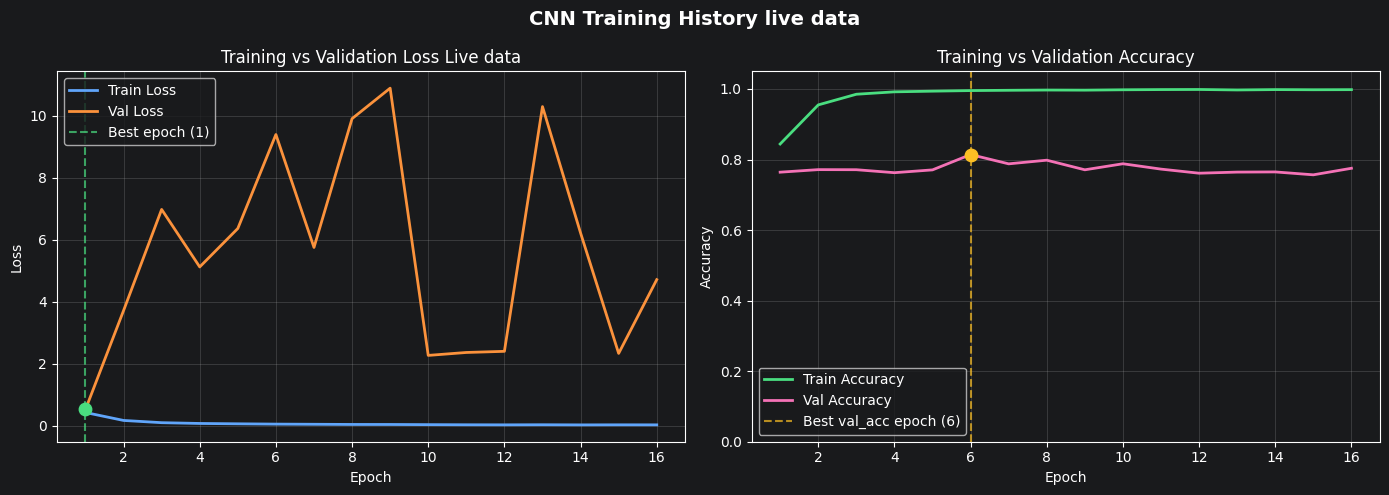


CNN TRAINING DIAGNOSIS
----------------------------------------
Total epochs run      : 16
Best val_loss         : 0.5181  (epoch 1)
Best val_accuracy     : 0.8140  (epoch 6)
Train accuracy @ best : 0.8440
Val accuracy   @ best : 0.7641
Train/Val gap         : 0.0799  OVERFIT


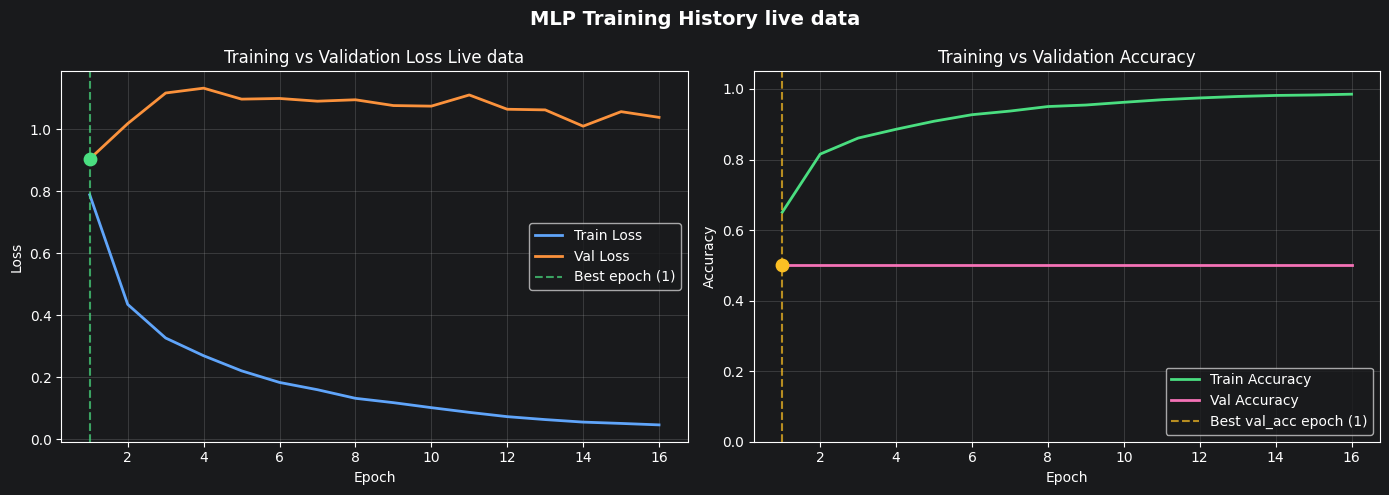


MLP TRAINING DIAGNOSIS
----------------------------------------
Total epochs run      : 16
Best val_loss         : 0.9037  (epoch 1)
Best val_accuracy     : 0.5000  (epoch 1)
Train accuracy @ best : 0.6504
Val accuracy   @ best : 0.5000
Train/Val gap         : 0.1504  OVERFIT


In [74]:
ASSETS_PATH.mkdir(parents=True, exist_ok=True)

def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} Training History live data", fontsize=14, fontweight="bold")

    epochs_range = range(1, len(history.history["loss"]) + 1)

    # best epoch indices
    best_epoch_idx     = int(np.argmin(history.history["val_loss"]))
    best_epoch         = best_epoch_idx + 1
    best_val_loss      = history.history["val_loss"][best_epoch_idx]

    best_val_acc_idx   = int(np.argmax(history.history["val_accuracy"]))
    best_val_acc_epoch = best_val_acc_idx + 1
    best_val_acc       = history.history["val_accuracy"][best_val_acc_idx]

    # gap at best epoch — not final epoch
    gap = (history.history['accuracy'][best_epoch_idx] -
           history.history['val_accuracy'][best_epoch_idx])

    # ── Subplot 1: Loss
    ax1.plot(epochs_range, history.history["loss"],
             label="Train Loss", color="#60a5fa", linewidth=2)
    ax1.plot(epochs_range, history.history["val_loss"],
             label="Val Loss",   color="#fb923c", linewidth=2)

    ax1.axvline(best_epoch, color="#4ade80", linestyle="--", alpha=0.7,
                label=f"Best epoch ({best_epoch})")
    ax1.scatter([best_epoch], [best_val_loss], color="#4ade80", s=80, zorder=5)

    ax1.set_title("Training vs Validation Loss Live data")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    #  Subplot 2: Accuracy
    ax2.plot(epochs_range, history.history["accuracy"],
             label="Train Accuracy", color="#4ade80", linewidth=2)
    ax2.plot(epochs_range, history.history["val_accuracy"],
             label="Val Accuracy",   color="#f472b6", linewidth=2)

    ax2.axvline(best_val_acc_epoch, color="#fbbf24", linestyle="--", alpha=0.7,
                label=f"Best val_acc epoch ({best_val_acc_epoch})")
    ax2.scatter([best_val_acc_epoch], [best_val_acc],
                color="#fbbf24", s=80, zorder=5)

    ax2.set_title("Training vs Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim([0, 1.05])
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    save_path = ASSETS_PATH / f"{model_name.lower()}_training_history.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    # Diagnosis at best epoch
    print(f"\n{model_name} TRAINING DIAGNOSIS")
    print("-" * 40)
    print(f"Total epochs run      : {len(history.history['loss'])}")
    print(f"Best val_loss         : {best_val_loss:.4f}  (epoch {best_epoch})")
    print(f"Best val_accuracy     : {best_val_acc:.4f}  (epoch {best_val_acc_epoch})")
    print(f"Train accuracy @ best : {history.history['accuracy'][best_epoch_idx]:.4f}")
    print(f"Val accuracy   @ best : {history.history['val_accuracy'][best_epoch_idx]:.4f}")
    print(f"Train/Val gap         : {gap:.4f}  {'OVERFIT' if gap > 0.05 else 'OK'}")


# ── Call for all three models
plot_history(lstm_history, "LSTM")
plot_history(cnn_history,  "CNN")
plot_history(mlp_history,  "MLP")

### Evaluate on Validation set

LSTM — LIVE DATA VALIDATION SET RESULTS
              precision    recall  f1-score   support

      Normal     0.9907    0.9971    0.9939      1382
        Leak     1.0000    0.9747    0.9872      1382
    Blockage     0.9815    1.0000    0.9907      1382

    accuracy                         0.9906      4146
   macro avg     0.9907    0.9906    0.9906      4146
weighted avg     0.9907    0.9906    0.9906      4146



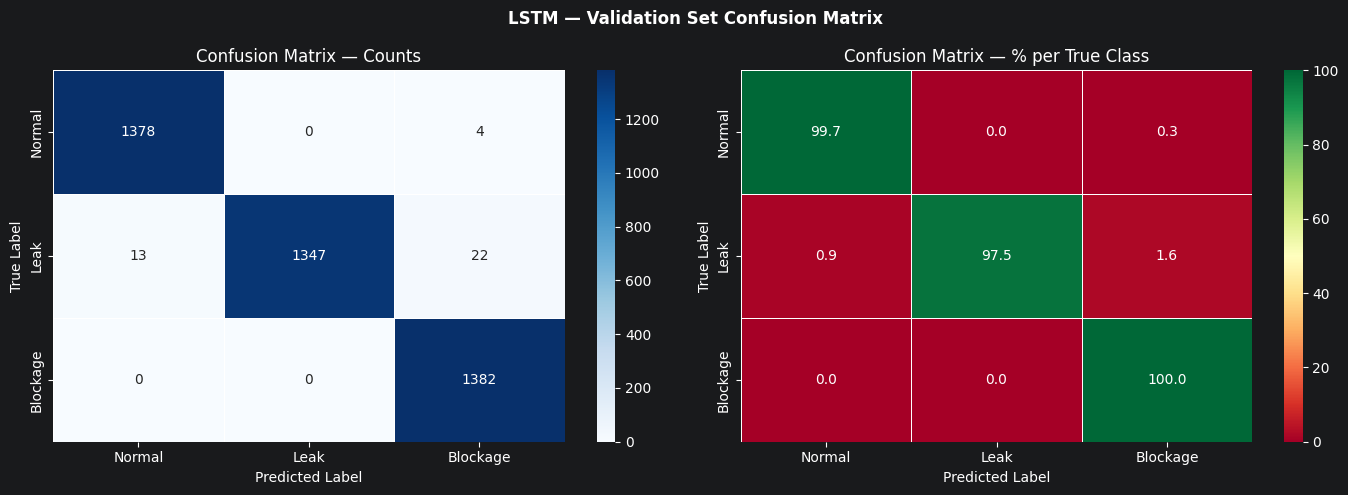

CNN — LIVE DATA VALIDATION SET RESULTS
              precision    recall  f1-score   support

      Normal     0.8791    0.5000    0.6375      1382
        Leak     0.6146    0.7974    0.6942      1382
    Blockage     0.8775    0.9949    0.9325      1382

    accuracy                         0.7641      4146
   macro avg     0.7904    0.7641    0.7547      4146
weighted avg     0.7904    0.7641    0.7547      4146



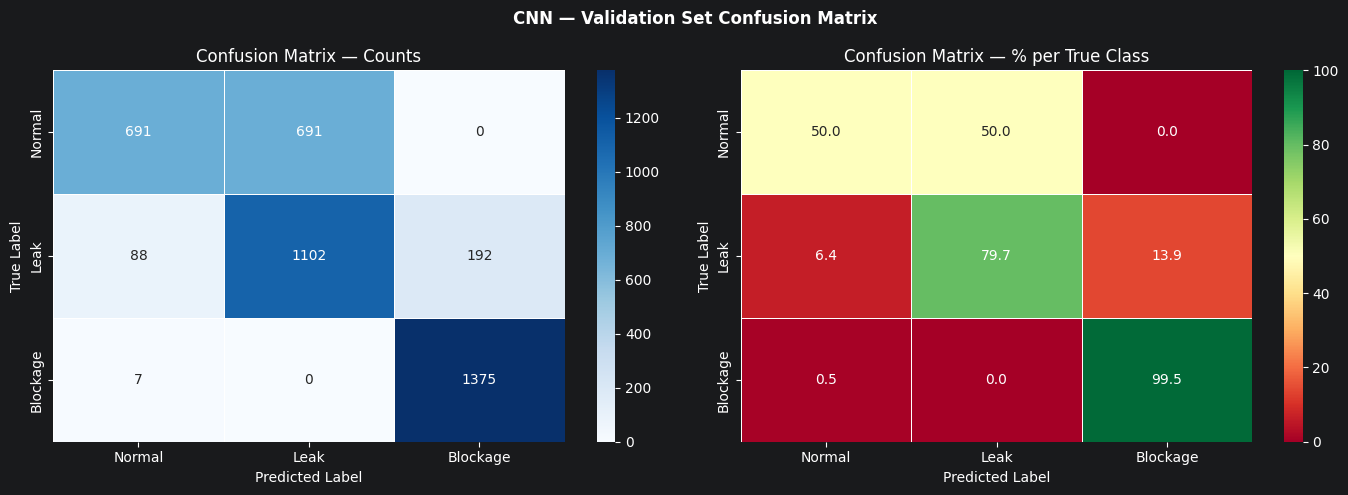

MLP — LIVE DATA VALIDATION SET RESULTS
              precision    recall  f1-score   support

      Normal     0.0000    0.0000    0.0000      1382
        Leak     1.0000    0.5000    0.6667      1382
    Blockage     0.4000    1.0000    0.5714      1382

    accuracy                         0.5000      4146
   macro avg     0.4667    0.5000    0.4127      4146
weighted avg     0.4667    0.5000    0.4127      4146



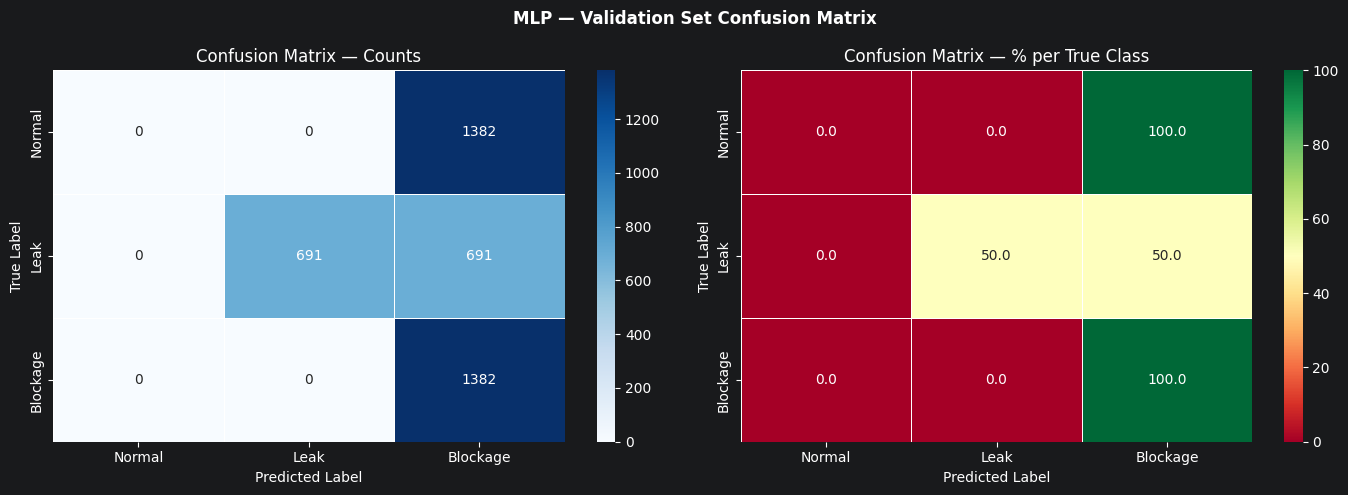

In [75]:
def evaluate_model(model, model_name, X_val_seq, y_val_cat):
    """
    - Classification report
    - Confusion matrix (counts + percentages)
    - Leak recall extraction
    - Saves confusion matrix to assets folder
    """
    CLASS_NAMES = ["Normal", "Leak", "Blockage"]

    # Predict
    y_pred_prob = model.predict(X_val_seq, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = np.argmax(y_val_cat,   axis=1)

    # Classification Report
    print("=" * 50)
    print(f"{model_name} — LIVE DATA VALIDATION SET RESULTS")
    print("=" * 50)
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    ))

    # Leak Recall
    leak_recall = recall_score(y_true, y_pred, labels=[1], average=None)[0]

    # Confusion Matrix
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title("Confusion Matrix — Counts")
    axes[0].set_ylabel("True Label")
    axes[0].set_xlabel("Predicted Label")

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="RdYlGn",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
    axes[1].set_title("Confusion Matrix — % per True Class")
    axes[1].set_ylabel("True Label")
    axes[1].set_xlabel("Predicted Label")

    plt.suptitle(f"{model_name} — Validation Set Confusion Matrix",
                 fontweight="bold")
    plt.tight_layout()

    save_path = ASSETS_PATH / f"{model_name.lower()}_val_confusion.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    return leak_recall


# Run for all three models
leak_recall_lstm = evaluate_model(lstm_model, "LSTM", X_val_seq, y_val_cat)
leak_recall_cnn  = evaluate_model(cnn_model,  "CNN",  X_val_seq, y_val_cat)
leak_recall_mlp  = evaluate_model(mlp_model,  "MLP",  X_val_seq, y_val_cat)


 Loaded best checkpoint: lstm_best.keras

LSTM — FINAL TEST SET RESULTS
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000      1382
        Leak     0.6667    1.0000    0.8000      1382
    Blockage     1.0000    0.5000    0.6667      1382

    accuracy                         0.8333      4146
   macro avg     0.8889    0.8333    0.8222      4146
weighted avg     0.8889    0.8333    0.8222      4146



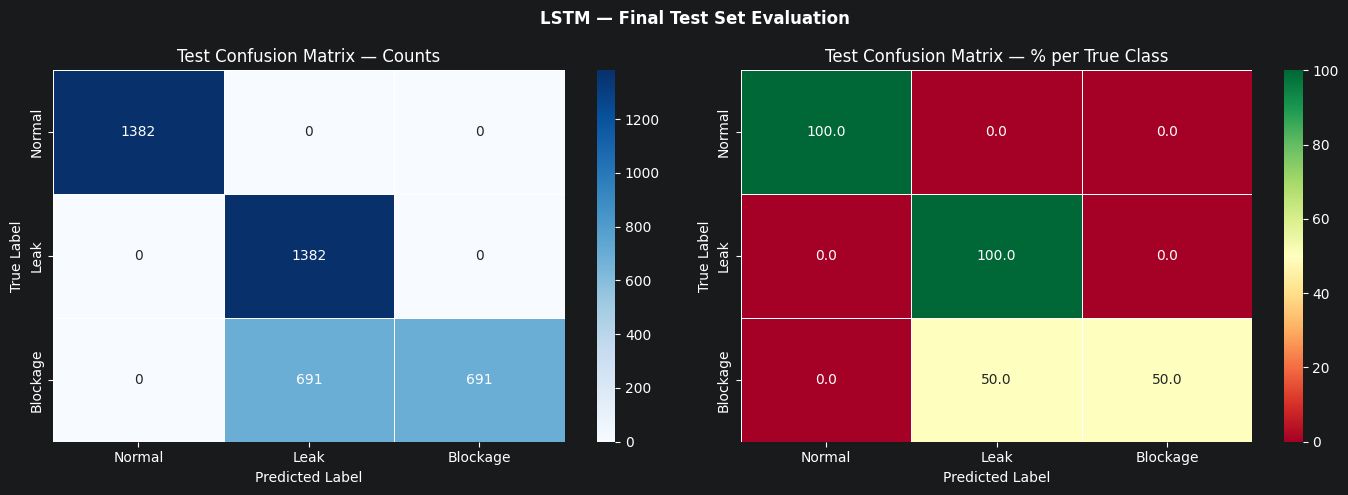

In [76]:
# Load best checkpoint
best_model = load_model(artifacts_path/ "lstm_best_live_model.keras")
print(" Loaded best checkpoint: lstm_best.keras")

# Predict on test set
y_pred_prob_test = best_model.predict(X_test_seq, verbose=0)
y_pred_test      = np.argmax(y_pred_prob_test, axis=1)
y_true_test      = np.argmax(y_test_cat, axis=1)

# Final Classification Report
print("\n" + "=" * 50)
print("LSTM — FINAL TEST SET RESULTS")
print("=" * 50)
print(classification_report(
    y_true_test, y_pred_test,
    target_names=["Normal", "Leak", "Blockage"],
    digits=4
))

# Final Confusion Matrix
cm_test     = confusion_matrix(y_true_test, y_pred_test)
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Test Confusion Matrix — Counts")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

sns.heatmap(cm_test_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title("Test Confusion Matrix — % per True Class")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle("LSTM — Final Test Set Evaluation", fontweight="bold")
plt.tight_layout()
save_path = ASSETS_PATH /"lstm_test_confusion.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

 Loaded best checkpoint: cnn_best.keras

CNN — FINAL TEST SET RESULTS
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000      1382
        Leak     0.5184    0.9993    0.6826      1382
    Blockage     0.9900    0.0716    0.1336      1382

    accuracy                         0.6903      4146
   macro avg     0.8361    0.6903    0.6054      4146
weighted avg     0.8361    0.6903    0.6054      4146



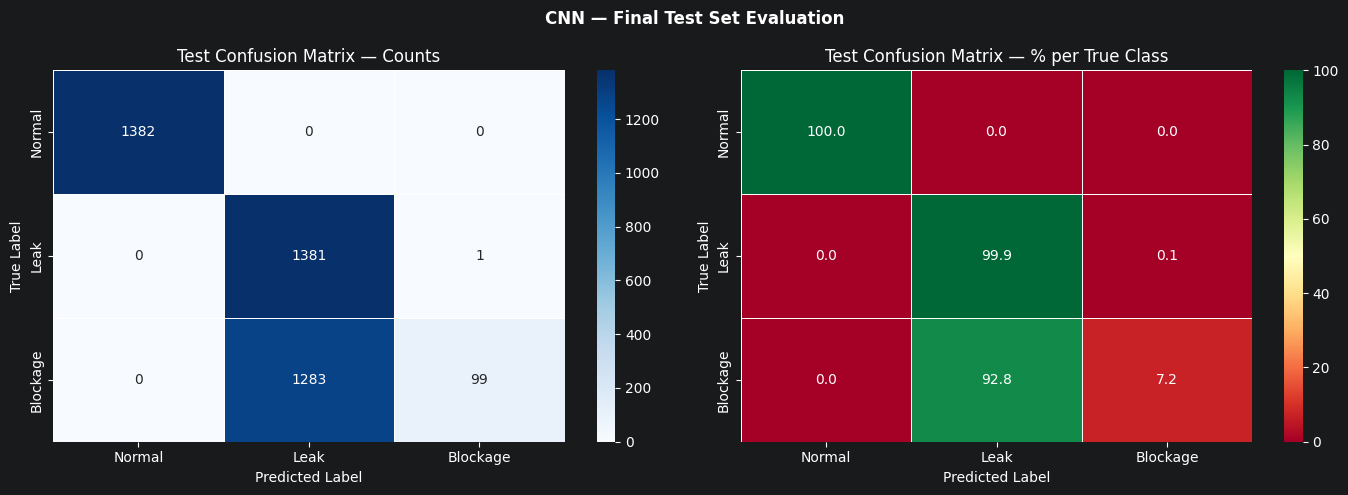

In [77]:
# Load best checkpoint
best_model = load_model(artifacts_path/ "cnn_best_live_model.keras")
print(" Loaded best checkpoint: cnn_best.keras")

# Predict on test set
y_pred_prob_test = best_model.predict(X_test_seq, verbose=0)
y_pred_test      = np.argmax(y_pred_prob_test, axis=1)
y_true_test      = np.argmax(y_test_cat, axis=1)

# Final Classification Report
print("\n" + "=" * 50)
print("CNN — FINAL TEST SET RESULTS")
print("=" * 50)
print(classification_report(
    y_true_test, y_pred_test,
    target_names=["Normal", "Leak", "Blockage"],
    digits=4
))

# Final Confusion Matrix
cm_test     = confusion_matrix(y_true_test, y_pred_test)
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Test Confusion Matrix — Counts")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

sns.heatmap(cm_test_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title("Test Confusion Matrix — % per True Class")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle("CNN — Final Test Set Evaluation", fontweight="bold")
plt.tight_layout()
save_path = ASSETS_PATH /"cnn_test_confusion.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()